<a href="https://www.kaggle.com/code/lalit7881/used-car-price-prediction-51?scriptVersionId=343438552" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/Pakistan_Used_Cars.csv
/kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/BMW_Cars_Pakistan.csv
/kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/Used_Car_Prices.csv


In [2]:
# Suppress warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

# matplotlib inline setup and backend switching
import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
plt.switch_backend('Agg')

%matplotlib inline

# Import useful libraries
import numpy as np
import pandas as pd
import seaborn as sns

# For reproducibility
np.random.seed(42)

print('Imports and setup complete.')

Imports and setup complete.


In [3]:
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    """Helper to dynamically resolve the file path for datasets. 
    This is especially handy when notebooks are run on different environments like Kaggle."""
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Data file resolver function is ready.')

Data file resolver function is ready.


In [4]:
# Load the Used Car Price dataset
try:
    used_car_file = resolve_data_file(file_name='Used_Car_Prices.csv', suffixes=['.csv'])
    used_car_df = pd.read_csv(used_car_file, encoding='ascii', delimiter=',')
    print(f'Loaded Used Car Price Data from: {used_car_file}')
except Exception as e:
    print('Error encountered while loading Used Car Price Data:', e)

# Quick look at the dataset
print(used_car_df.head())

Loaded Used Car Price Data from: /kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/Used_Car_Prices.csv
     brand  km_driven    fuel         owner  selling_price
0   Maruti     145500  Diesel   First Owner         450000
1    Skoda     120000  Diesel  Second Owner         370000
2    Honda     140000  Petrol   Third Owner         158000
3  Hyundai     127000  Diesel   First Owner         225000
4   Maruti     120000  Petrol   First Owner         130000


In [5]:
try:
    bmw_car_file = resolve_data_file(file_name='BMW_Cars_Pakistan.csv', suffixes=['.csv'])
    bmw_car_df = pd.read_csv(bmw_car_file, encoding='ascii', delimiter=',')
    print(f'Loaded BMW Car Data from: {bmw_car_file}')
except Exception as e:
    print('Error encountered while loading BMW Car Data:', e)

# Quick look at the BMW dataset
print(bmw_car_df.head())

Loaded BMW Car Data from: /kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/BMW_Cars_Pakistan.csv
   Unnamed: 0                                           Car Name  \
0           0  BMW 7 Series 5th (F01) Generation 2013 ActiveH...   
1           1                    BMW X5  2012 xDrive50i for Sale   
2           2          BMW 7 Series  2017 740 Le xDrive for Sale   
3           3        BMW 2 Series  2021 218i Gran Coupe for Sale   
4           4                BMW X1  2017 sDrive18i A/T for Sale   

   Auction Rating  Model Year  Mileage Fuel Type  Engine Capacity  \
0             NaN        2013    52000    Hybrid           3000.0   
1             8.0        2012   102148    Petrol           4400.0   
2             NaN        2017    48000    Hybrid           2000.0   
3             9.3        2021    68064    Petrol           1500.0   
4             8.6        2017   138928    Petrol           1500.0   

  Transmission Engine Unit  Price (PKR)  
0    Automatic

In [6]:
# For the used car price data, let's perform some basic cleaning
print('Used Car Price Data info:')
print(used_car_df.info())

Used Car Price Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB
None


In [7]:
# Check for missing values
print('Missing values in Used Car Price Data:')
print(used_car_df.isnull().sum())

Missing values in Used Car Price Data:
brand            0
km_driven        0
fuel             0
owner            0
selling_price    0
dtype: int64


In [8]:
# Assuming minimal cleaning is needed, we'll drop duplicates if any
before = used_car_df.shape[0]
used_car_df.drop_duplicates(inplace=True)
after = used_car_df.shape[0]
print(f'Dropped {before - after} duplicate rows.')

Dropped 1678 duplicate rows.


In [9]:
# For the predictor, we will one-hot encode categorical variables
categorical_cols = ['brand', 'fuel', 'owner']
used_car_df_encoded = pd.get_dummies(used_car_df, columns=categorical_cols, drop_first=True)


In [10]:
print('Data after encoding:')
print(used_car_df_encoded.head())

Data after encoding:
   km_driven  selling_price  brand_Ashok  brand_Audi  brand_BMW  \
0     145500         450000        False       False      False   
1     120000         370000        False       False      False   
2     140000         158000        False       False      False   
3     127000         225000        False       False      False   
4     120000         130000        False       False      False   

   brand_Chevrolet  brand_Daewoo  brand_Datsun  brand_Fiat  brand_Force  ...  \
0            False         False         False       False        False  ...   
1            False         False         False       False        False  ...   
2            False         False         False       False        False  ...   
3            False         False         False       False        False  ...   
4            False         False         False       False        False  ...   

   brand_Toyota  brand_Volkswagen  brand_Volvo  fuel_Diesel  fuel_LPG  \
0         False       

## EDA

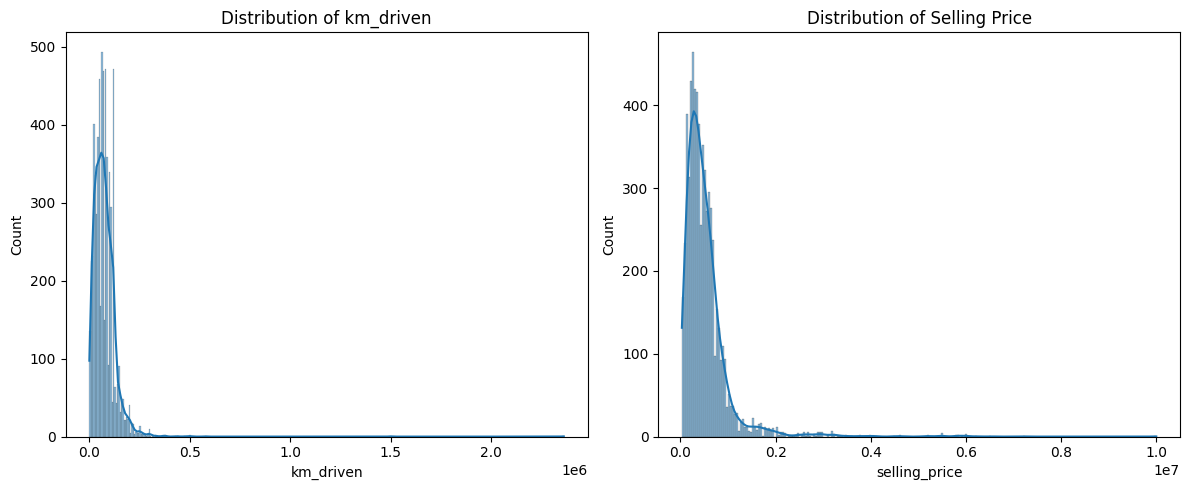

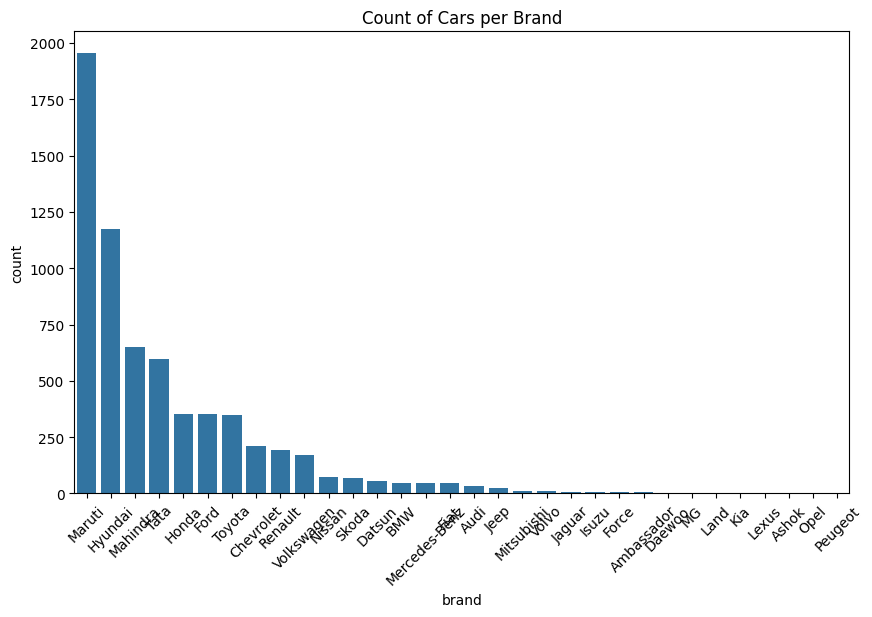

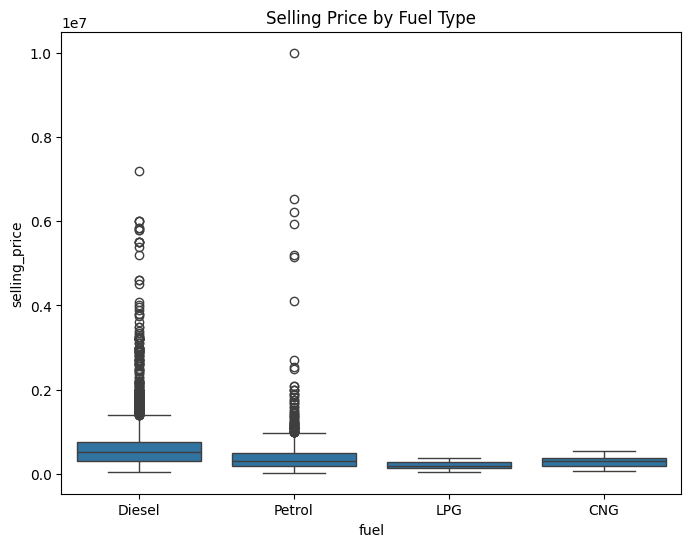

In [11]:
# Histograms for numerical columns (km_driven and selling_price)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(used_car_df['km_driven'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of km_driven')

sns.histplot(used_car_df['selling_price'], kde=True, ax=ax[1])
ax[1].set_title('Distribution of Selling Price')
plt.tight_layout()
plt.show()

# Count plot for categorical variable: brand
plt.figure(figsize=(10, 6))
sns.countplot(data=used_car_df, x='brand', order=used_car_df['brand'].value_counts().index)
plt.title('Count of Cars per Brand')
plt.xticks(rotation=45)
plt.show()

# Box plot to inspect selling_price across different fuel types
plt.figure(figsize=(8, 6))
sns.boxplot(data=used_car_df, x='fuel', y='selling_price')
plt.title('Selling Price by Fuel Type')
plt.show()


BMW Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       344 non-null    int64  
 1   Car Name         344 non-null    object 
 2   Auction Rating   27 non-null     float64
 3   Model Year       344 non-null    int64  
 4   Mileage          344 non-null    int64  
 5   Fuel Type        344 non-null    object 
 6   Engine Capacity  344 non-null    float64
 7   Transmission     344 non-null    object 
 8   Engine Unit      344 non-null    object 
 9   Price (PKR)      297 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 27.0+ KB
None
Missing values in BMW Car Data:
Unnamed: 0           0
Car Name             0
Auction Rating     317
Model Year           0
Mileage              0
Fuel Type            0
Engine Capacity      0
Transmission         0
Engine Unit          0
Price (PKR)         4

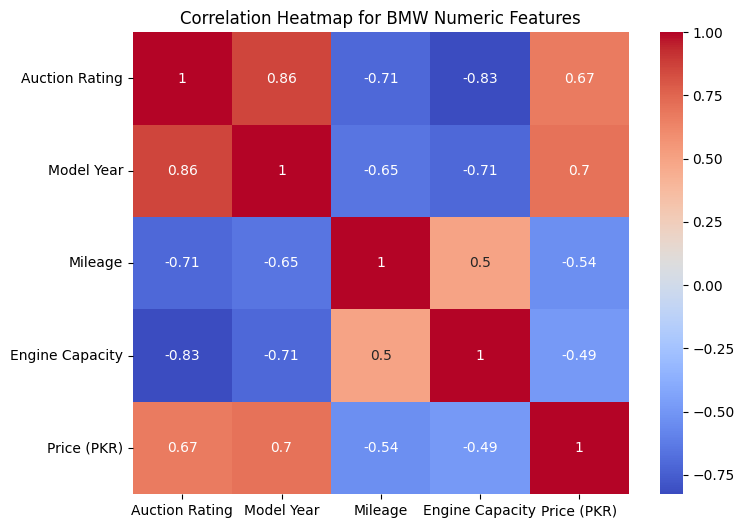

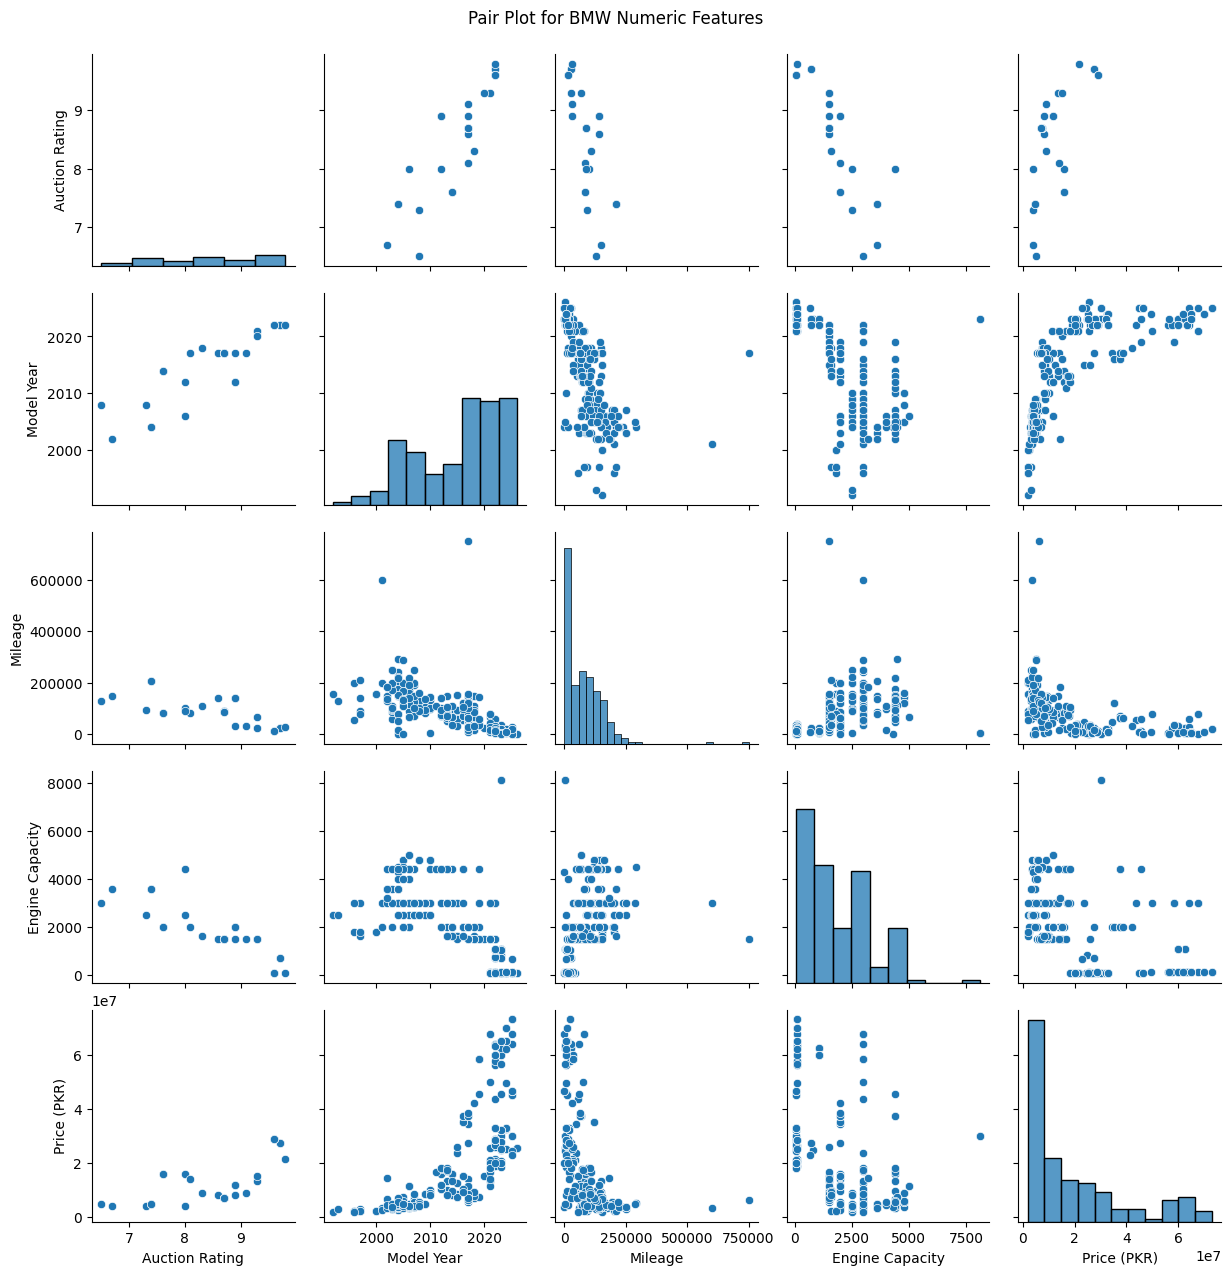

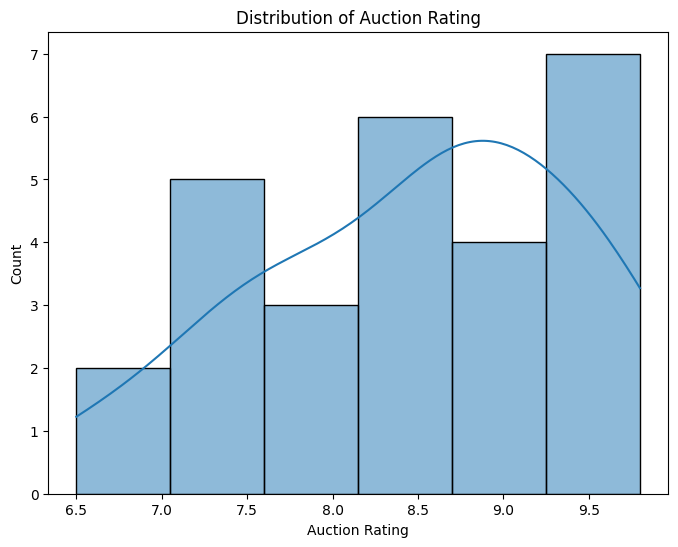

In [12]:
# Clean BMW data: check for duplicates and missing values
print('BMW Data info:')
print(bmw_car_df.info())

print('Missing values in BMW Car Data:')
print(bmw_car_df.isnull().sum())

# If there are extra columns such as an unnamed index, drop it
if 'Unnamed: 0' in bmw_car_df.columns:
    bmw_car_df.drop(columns=['Unnamed: 0'], inplace=True)

# Correlation heatmap for numeric columns (only if there are 4 or more numeric columns)
numeric_df = bmw_car_df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap for BMW Numeric Features')
    plt.show()

# Pair plot of numeric features
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot for BMW Numeric Features', y=1.02)
plt.show()

# Histogram for Auction Rating
plt.figure(figsize=(8, 6))
sns.histplot(bmw_car_df['Auction Rating'], kde=True)
plt.title('Distribution of Auction Rating')
plt.show()

Linear Regression R2 Score: 0.515


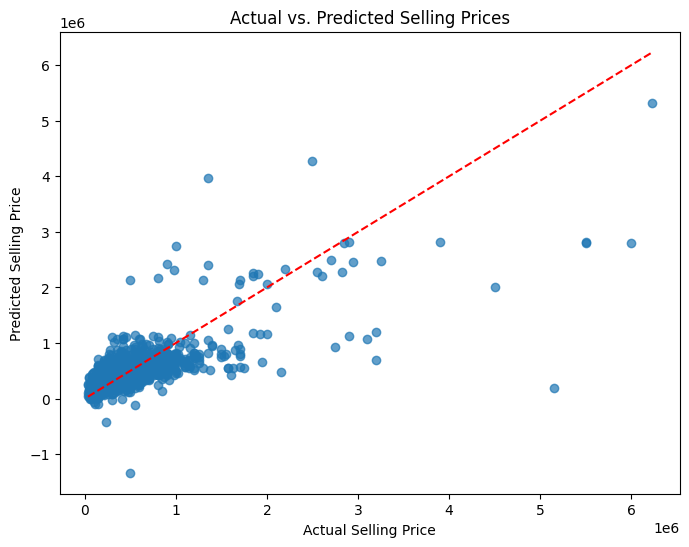

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define features and target
X = used_car_df_encoded.drop('selling_price', axis=1)
y = used_car_df_encoded['selling_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and calculate the R2 score
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f'Linear Regression R2 Score: {score:.3f}')

# Plot predicted vs actual selling prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Selling Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## Thank you..pls upvote!!!!!